## Preamble

In [22]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

nz=201; nx=201; h=10

fpeak=7; dt=0.003; nt=1000

ntr=201

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

nzsnap=249; nxsnap=249; nsnap=51
def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/GradientTest',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

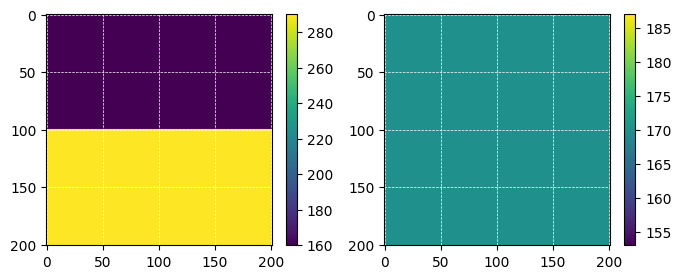

In [2]:
# True
!makevel nz=100 nx=$nx v000=160 > c1
!makevel nz=101 nx=$nx v000=290 > c2
!cat c1 c2 > tmp && transp < tmp n1=$nx > cel
!rm c1 c2 tmp
#density=0.4*np.pi
!makevel nz=$nz nx=$nx v000=1.25663708 > one
!cat cel one > true

# Background
!makevel nz=$nz nx=$nx v000=170 > cel
!cat cel one > init

#plot
plt.figure(figsize=(8,3))
true=read('true',(2*nx,nz))
init=read('init',(2*nx,nz))
plt.subplot(1,2,1); imshow(true[:,:nx])
plt.subplot(1,2,2); imshow(init[:,:nx])

1.0686971 3.5108366
1.0 1.0


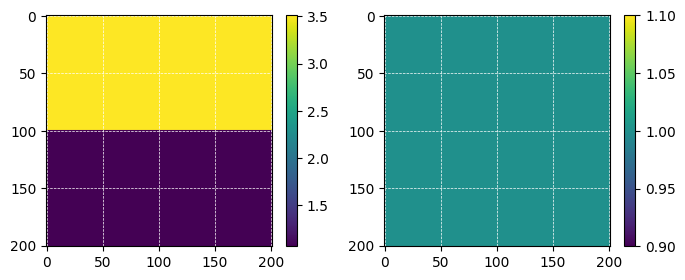

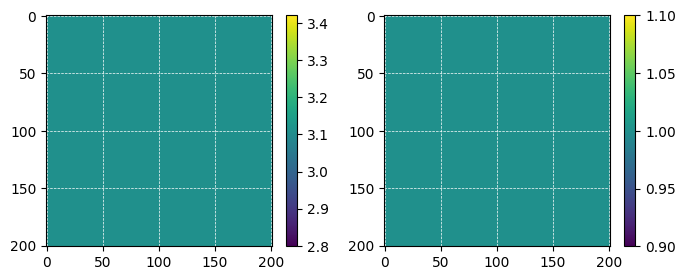

In [7]:
def epsrmur2celmu(epsr,mur):
    cel = 299.79563548 /np.sqrt(epsr*mur)
    mu  = 0.4*np.pi*mur
    return cel,mu

def celmu2epsrmur(cel,mu):
    mur = mu/(0.4*np.pi)
    epsr= (299.79563548/cel)**2/mur
    return epsr,mur

model=read('true',(2*nx,nz))
epsr, mur = celmu2epsrmur(model[:,:nx],model[:,nx:])
model=np.concatenate((epsr,mur),axis=1)
model.T.astype('float32').tofile('true_GPR')

model=read('init',(2*nx,nz))
epsr, mur = celmu2epsrmur(model[:,:nx],model[:,nx:])
model=np.concatenate((epsr,mur),axis=1)
model.T.astype('float32').tofile('init_GPR')


#plot
true=read('true_GPR',(2*nx,nz))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(true[:,:nx]); print(true[:,:nx].min(),true[:,:nx].max())
plt.subplot(1,2,2); imshow(true[:,nx:]); print(true[:,nx:].min(),true[:,nx:].max())

init=read('init_GPR',(2*nx,nz))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(init[:,:nx])
plt.subplot(1,2,2); imshow(init[:,nx:])

In [ ]:
#topo
!makevel nz=1   nx=$nx v000=75  > topo

In [23]:
%%writefile setup_default

MODEL_SIZE              '201   201   1'
MODEL_SPACING           '1.5   1.5   1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'true_GPR'
MODEL_ATTRIBUTES        'epsr mur' # sgma'
NAIRL                    0

ACQUI_GEOMETRY          spread
FS                      '75 75  0'
FR                      '75  0  0'
DR                      '0  1.5 0'
NR                      201

SU_SCALCO   -10

SCOMP                   Ey
RCOMP                   Ey #'p vz'

WAVELET_TYPE            ricker
#T0                      0.5
#FILE_WAVELET            'fricker_dt6000.su'

IF_HICKS        F
IF_BLOOM        F

IF_USE_RANDOM   F

NT           1000
DT           0.003
FPEAK        7

SNAPSHOT                'Ey Hx Hz'


### for inversion ###
FILE_DATA_PREFIX        'results_obs/Ru_Shot'
WEIGHTING               'none'

PARAMETER               'epsr:1.06:3.52'

SMOOTHING               'none'
#PRECO         'z^0'

#DESCENT_DIR     'random'  #'-curr%pg'

#LS_SCALING  'none'

IF_USE_CHECKPOINT        F

Overwriting setup_default


In [9]:
!make

#System
(cd ../../Modules/System; make)
make[1]: Entering directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/System'

make[1]: Leaving directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/System'
#Etc
(cd ../../Modules/Etc; make)
make[1]: Entering directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/Etc'

make[1]: Leaving directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/Etc'
#Signal
(cd ../../Modules/Signal; make)
make[1]: Entering directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/Signal'

make[1]: Leaving directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/Signal'
#Modeling
(cd ../../Modules/Modeling; make)
make[1]: Entering directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/Modeling'

make[1]: Leaving directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/Modeling'
#Kernel
(cd ../../Modules/Kernel; make App=FWI)
make[1]: Entering directory '/home/joey/Codes/GitHub/SeisJIMU/Modules/Kernel'
m_empirical.f90 m_parametrizer_epsr-mur-sgma.f90 m_querypoint.f90 m_weighter.f90 m_preconditio

## TE

### Ey-Ey

#### Obs & Syn data

In [10]:
!cp setup_default setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 635568 Jun 25 00:51 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: d8a992d
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/25/2026
System time: 00:52:05
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0

In [11]:
!cp setup_default setup
!echo 'FILE_MODEL  init_GPR' >> setup
!echo "DIR_OUT     results_syn" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 635568 Jun 25 00:51 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: d8a992d
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/25/2026
System time: 00:53:04
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0

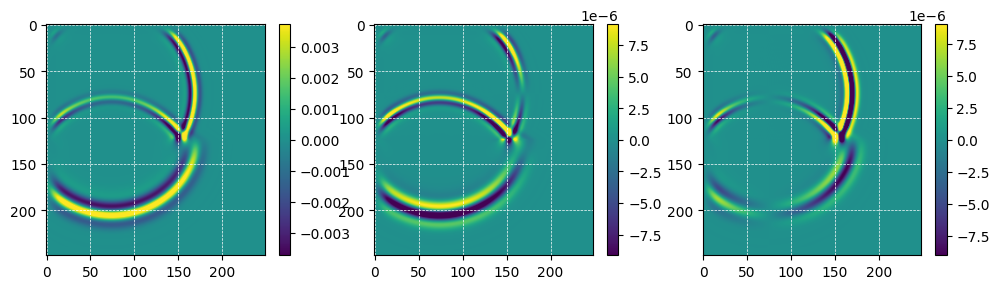

In [12]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results_obs/snap_fld_u%Ey',(51,249,249)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results_obs/snap_fld_u%Hx',(51,249,249)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results_obs/snap_fld_u%Hz',(51,249,249)),perc=98)

In [16]:
here =read_snap('results_obs/snap_fld_u%Ey',(51,249,249))
there=read_snap('/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Demo/04_GradientTest/results_obs/snap_fld_u%p',(51,249,249))
print( np.sum(np.abs(there)) / np.sum(np.abs(here)) )

here =read_snap('results_obs/snap_fld_u%Hx',(51,249,249))
there=read_snap('/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Demo/04_GradientTest/results_obs/snap_fld_u%vz',(51,249,249))
print( np.sum(np.abs(there)) / np.sum(np.abs(here)) )

here =read_snap('results_obs/snap_fld_u%Hz',(51,249,249))
there=read_snap('/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Demo/04_GradientTest/results_obs/snap_fld_u%vx',(51,249,249))
print( np.sum(np.abs(there)) / np.sum(np.abs(here)) )

333.33853
333.33353
333.33432


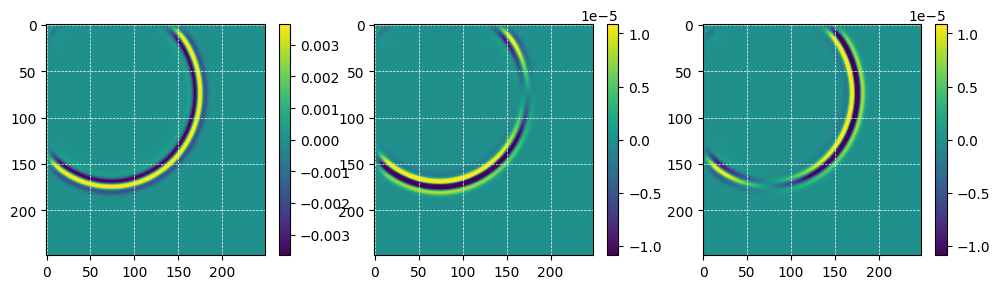

In [17]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results_syn/snap_fld_u%Ey',(51,249,249)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results_syn/snap_fld_u%Hx',(51,249,249)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results_syn/snap_fld_u%Hz',(51,249,249)),perc=98)

In [18]:
here =read_snap('results_syn/snap_fld_u%Ey',(51,249,249))
there=read_snap('/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Demo/04_GradientTest/results_syn/snap_fld_u%p',(51,249,249))
print( np.sum(np.abs(there)) / np.sum(np.abs(here)) )

here =read_snap('results_syn/snap_fld_u%Hx',(51,249,249))
there=read_snap('/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Demo/04_GradientTest/results_syn/snap_fld_u%vz',(51,249,249))
print( np.sum(np.abs(there)) / np.sum(np.abs(here)) )

here =read_snap('results_syn/snap_fld_u%Hz',(51,249,249))
there=read_snap('/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Demo/04_GradientTest/results_syn/snap_fld_u%vx',(51,249,249))
print( np.sum(np.abs(there)) / np.sum(np.abs(here)) )

333.3388
333.33258
333.33258


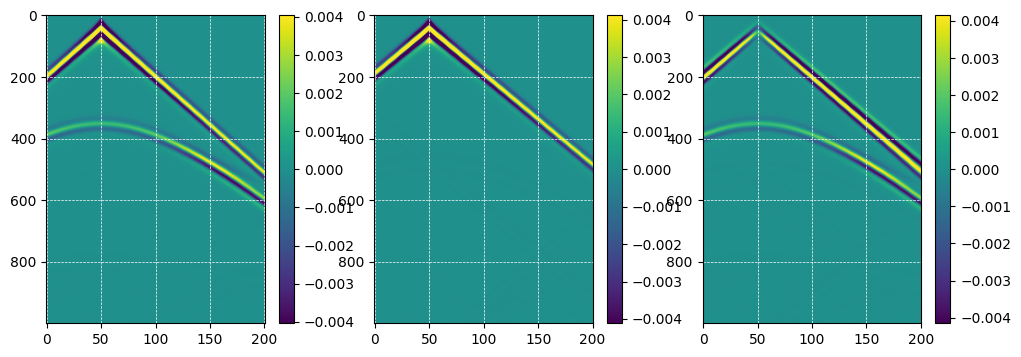

In [24]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_obs/Ru_Shot0001.su') \
                          -read_su('results_syn/Ru_Shot0001.su'),perc=98)

#### Gradient

In [19]:
!cp setup_default setup
!echo 'FILE_MODEL   init_GPR' >> setup
# !echo "PARAMETER   'mur:1:1.2'" >> setup
run(app='../../exe/GradientTest')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 joey joey 37 Jun 25 00:51 ../../exe/GradientTest -> gradienttest_TE_FDSG_O4_epsr-mur-sgma
 Git Commit: 8f192ec
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/25/2026
System time: 00:58:55
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI       
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *V

 Elapsed time to load boundary            5.33211231E-03
 Elapsed time to update E        4.64706123E-02
 Elapsed time to rm source E     2.67422199E-03
 Elapsed time to update H          4.18749154E-02
 Total elapsed time for forward (min)   1.60586438E-03
  ---------------------------- 
 Elapsed time to add adjsource E    1.82738006E-02
 Elapsed time to update adj E       4.03884351E-02
 Elapsed time to update adj H         4.87883091E-02
 Elapsed time to extract&write fields        0.00000000    
 Elapsed time to correlate                   4.29779291E-04
 Total elapsed time for adjoint&correlate (min)   1.79800543E-03
 Total elapsed time (min):   3.40386969E-03
 Viewing the snapshots (if written) with SU ximage/xmovie:
 ximage < snap_rfield%*  n1=249 perc=99
 xmovie < snap_rfield%*  n1=249 n2=249 clip=?e-?? loop=2 title=%g
 ximage < snap_*  n1=201 perc=99
 xmovie < snap_*  n1=201 n2=201 clip=?e-?? loop=2 title=%g
 ----  Assemble  ----
 ---------------------------------
         END

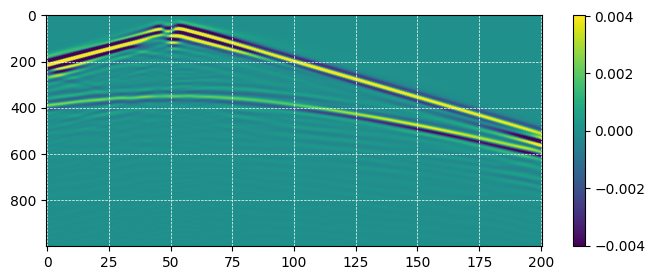

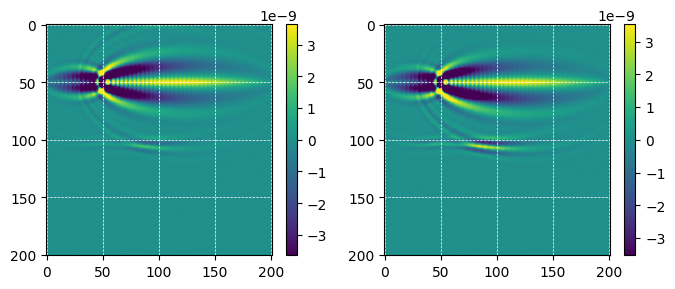

In [25]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results/qp0%g'), perc=98)
plt.subplot(1,2,2); imshow(read('results/qp0%pg'),perc=98)


# corr=read('results/correlate_gradient',n=(3*nx,nz)) #gmur gepsr gsgma
# plt.figure(figsize=(16,3))
# plt.subplot(1,4,1); imshow(corr[:,:nx],perc=98)
# plt.subplot(1,4,2); imshow(corr[:,nx:2*nx],perc=98)
# plt.subplot(1,4,3); imshow(corr[:,2*nx:],perc=98)

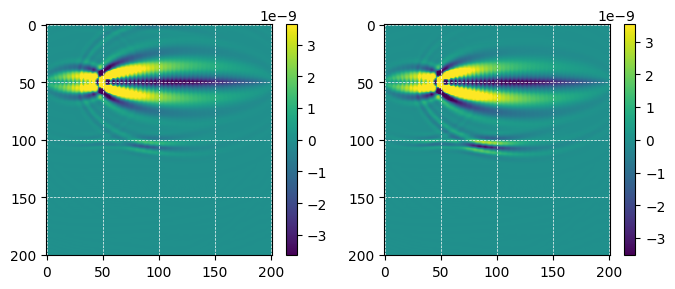

In [26]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(-read('results/qp0%g'), perc=98)
plt.subplot(1,2,2); imshow(-read('results/qp0%pg'),perc=98)

#### gradienttest on gepsr

In [157]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'mur:1:1.2'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/GradientTest  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   742357120.       744541056.      -2.18393608E+11  -17778872.0       8.14074738E-05 T
 1st cond   9.99999975E-05   722908160.       744541056.      -2.16328962E+11  -17778872.0       8.21844296E-05 T
 1st cond   1.00000005E-03   553254976.       744541056.      -1.91286067E+11  -17778872.0       9.29438975E-05 T
 1st cond   9.99999978E-03   181243232.       744541056.      -5.63297812E+10  -17778872.0       3.15621175E-04 T
 1st cond  0.100000001       140651680.       744541056.      -6.03889408E+09  -17778872.0       2.94406083E-03 T
 1st cond   1.00000000       159664768.       744541056.      -584876288.      -17778872.0       3.03976629E-02 T


In [163]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER  'epsr:4:10'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/GradientTest  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

rm: cannot remove 'results': No such file or directory
            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   3083194.25       3085124.75      -193050000.      -15009.2090       7.77477835E-05 T
 1st cond   9.99999975E-05   3065819.25       3085124.75      -193055008.      -15009.2090       7.77457608E-05 T
 1st cond   1.00000005E-03   2896431.25       3085124.75      -188693488.      -15009.2090       7.95428059E-05 T
 1st cond   9.99999978E-03   1636550.75       3085124.75      -144857408.      -15009.2090       1.03613682E-04 T
 1st cond  0.100000001       3194272.00       3085124.75       1091472.50      -15009.2090      -1.37513392E-02 F
 1st cond   1.00000000       5222945.00       3085124.75       2137820.25      -15009.2090      -7.02080037E-03 F


In [164]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER  'epsr:4:10'" >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/GradientTest  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond  -9.99999975E-06   3087070.00       3085124.75      -194525008.      -15009.2090       7.71582490E-05 F
 1st cond  -9.99999975E-05   3104528.25       3085124.75      -194035008.      -15009.2090       7.73530992E-05 F
 1st cond  -1.00000005E-03   3283511.50       3085124.75      -198386736.      -15009.2090       7.56563095E-05 F
 1st cond  -9.99999978E-03   5484260.00       3085124.75      -239913536.      -15009.2090       6.25609100E-05 F
 1st cond -0.100000001       28436928.0       3085124.75      -253518032.      -15009.2090       5.92037140E-05 F
 1st cond  -1.00000000       39553852.0       3085124.75      -36468728.0      -15009.2090       4.11563815E-04 F


In [19]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup

!echo "ALPHAS '1e1 1e2 1e3' " >> setup

!rm -r results
!../../exe/GradientTest  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   10.0000000       5336918.00       5427047.50      -9012.95020      -24909.4648       2.76374149     T
 1st cond   100.000000       6009372.00       5427047.50       5823.24512      -24909.4648      -4.27759171     F
 1st cond   1000.00000       6317715.50       5427047.50       890.668030      -24909.4648      -27.9671707     F


In [17]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'FILE_TOPO   topo' >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/GradientTest  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   12711979.0       12715998.0      -401900000.      -41123.4297       1.02322541E-04 T
 1st cond   9.99999975E-05   12675570.0       12715998.0      -404280000.      -41123.4297       1.01720165E-04 T
 1st cond   1.00000005E-03   12317369.0       12715998.0      -398628992.      -41123.4297       1.03162165E-04 T
 1st cond   9.99999978E-03   9867190.00       12715998.0      -284880800.      -41123.4297       1.44353107E-04 T
 1st cond  0.100000001       5950669.00       12715998.0      -67653288.0      -41123.4297       6.07855618E-04 T
 1st cond   1.00000000       7036272.50       12715998.0      -5679725.50      -41123.4297       7.24039041E-03 T


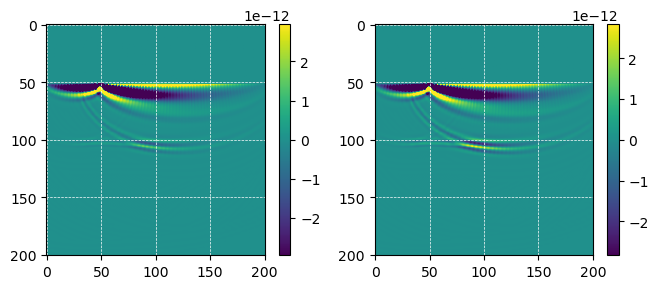

In [18]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('results/qp0%g' ),perc=98)
plt.subplot(1,3,2); imshow(read('results/qp0%pg'),perc=98)

#### gradienttest_TE_FDSG_O4_celerity-permeability on gcel

In [184]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
#!echo "PARAMETER   'epsr:4:10  mur:1:1.2'" >> setup
!echo "PARAMETER   'cel:80:150'" >> setup
!echo "JOB          gradient " >> setup
run(app='../../exe/FWI')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 48 Jun 24 13:01 ../../exe/FWI -> fwi_TE_FDSG_O4_celerity-permeability_Wolfe_NLCG_
 Git Commit: 9f095a2
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/24/2026
System time: 13:05:22
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|co

 Elapsed time to load boundary            2.66769528E-03
 Elapsed time to update E        4.28023934E-02
 Elapsed time to rm source E     2.40653753E-04
 Elapsed time to update H          4.67171371E-02
 Total elapsed time for forward (min)   1.54046470E-03
  ---------------------------- 
 Elapsed time to add adjsource E    1.54173374E-02
 Elapsed time to update adj E       5.50623536E-02
 Elapsed time to update adj H         4.68486547E-02
 Elapsed time to extract&write fields        0.00000000    
 Elapsed time to correlate                   1.10501051E-03
 Total elapsed time for adjoint&correlate (min)   1.97388930E-03
 Total elapsed time (min):   3.51435388E-03
 Viewing the snapshots (if written) with SU ximage/xmovie:
 ximage < snap_rfield%*  n1=249 perc=99
 xmovie < snap_rfield%*  n1=249 n2=249 clip=?e-?? loop=2 title=%g
 ximage < snap_*  n1=201 perc=99
 xmovie < snap_*  n1=201 n2=201 clip=?e-?? loop=2 title=%g
 ----  Assemble  ----
 ---------------------------------
         END

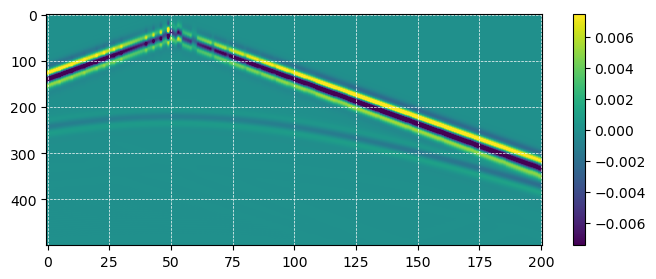

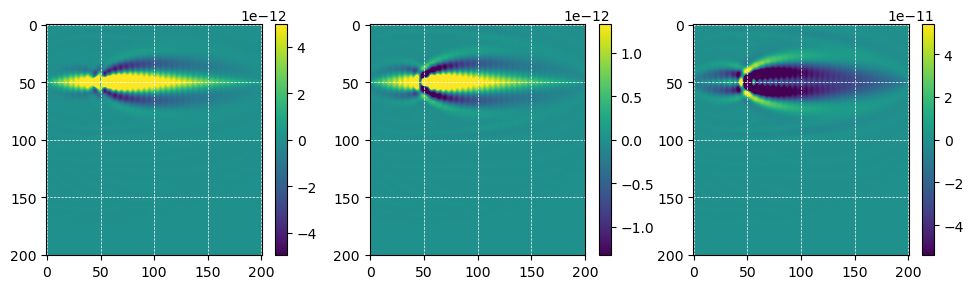

In [185]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz)) #gmur gepsr gsgma
plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(corr[:,:nx],perc=98)
plt.subplot(1,4,2); imshow(corr[:,nx:2*nx],perc=98)
plt.subplot(1,4,3); imshow(corr[:,2*nx:],perc=98)

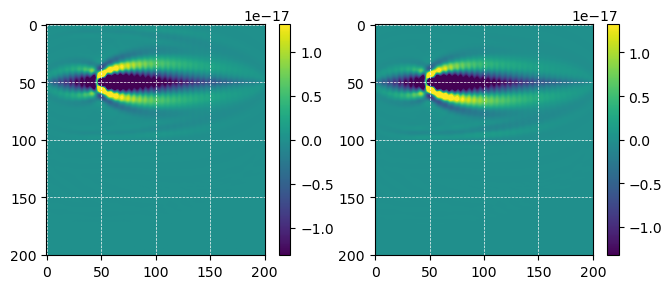

In [186]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('results/qp0%g' ),perc=98)
plt.subplot(1,3,2); imshow(read('results/qp0%pg'),perc=98)

In [188]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "PARAMETER   'cel:80:150'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/GradientTest  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   1.60436830E+11   1.60445170E+11  -8.33945600E+11  -110.272972       1.32230421E-10 T
 1st cond   9.99999975E-05   1.60362037E+11   1.60445170E+11  -8.31324160E+11  -110.272972       1.32647379E-10 T
 1st cond   1.00000005E-03   1.59611912E+11   1.60445170E+11  -8.33257406E+11  -110.272972       1.32339625E-10 T
 1st cond   9.99999978E-03   1.52294834E+11   1.60445170E+11  -8.15033549E+11  -110.272972       1.35298689E-10 T
 1st cond  0.100000001       9.58797332E+10   1.60445170E+11  -6.45654381E+11  -110.272972       1.70792575E-10 T
 1st cond   1.00000000       1.77387454E+11   1.60445170E+11   1.69422848E+10  -110.272972      -6.50874288E-09 F
